In [ ]:
import os
# Ruta base donde el usuario debe colocar el dataset
DATASET_DIR = "RUTA_AL_DATASET"

dirc_entrenamiento = os.path.join(DATASET_DIR, "Entrenamiento")
dirc_validacion = os.path.join(DATASET_DIR, "Validacion")
dirc_pruebas = os.path.join(DATASET_DIR, "Prueba")

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization
import matplotlib.pyplot as plt
import os
import numpy as np

entrenamiento_dir = dirc_entrenamiento
prueba_dir   = dirc_pruebas
val_dir  = dirc_validacion

CAMARA_HEIGHT, CAMARA_WIDTH = 640, 640
LIDAR_HEIGHT, LIDAR_WIDTH   = 19, 36
BATCH_SIZE = 16
EPOCHS = 30 

# 2. CARGA DE DATOS RGB
# Cámara
entrenamiento_camara_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(entrenamiento_dir, 'camara'),
    labels='inferred',
    label_mode='binary',
    image_size=(CAMARA_HEIGHT, CAMARA_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=True,
    seed = 42
)
val_camara_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(val_dir, 'camara'),
    labels='inferred',
    label_mode='binary',
    image_size=(CAMARA_HEIGHT, CAMARA_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=True,
    seed = 42
)

prueba_camara_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prueba_dir, 'camara'),
    labels='inferred',
    label_mode='binary',
    image_size=(CAMARA_HEIGHT, CAMARA_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    shuffle=True,
    seed = 42
)

# LiDAR 1
entrenamiento_lidar1_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(entrenamiento_dir, 'lidar1'),
    labels='inferred',
    label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed = 42
)
val_lidar1_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(val_dir, 'lidar1'),
    labels='inferred',
    label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed = 42
)
prueba_lidar1_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prueba_dir, 'lidar1'),
    labels='inferred',
    label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed = 42
)
# LiDAR 2
entrenamiento_lidar2_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(entrenamiento_dir, 'lidar2'),
    labels='inferred',
    label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH), 
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed = 42
)
val_lidar2_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(val_dir, 'lidar2'),
    labels='inferred',
    label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed = 42
)
prueba_lidar2_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prueba_dir, 'lidar2'),
    labels='inferred',
    label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    shuffle=True,
    seed = 42
)

# 3. COMBINACIÓN DE LOS DATASETS
def pair_datasets(camara_ds, lidar_ds, lidar2_ds):
    combined_ds = tf.data.Dataset.zip((camara_ds, lidar_ds, lidar2_ds))
    def format_pair(camara_batch, lidar_batch, lidar2_batch):
        return (
            {'camara_input': camara_batch[0], 'lidar_input': lidar_batch[0], 'lidar2_input': lidar2_batch[0]},
            camara_batch[1]
        )
    return combined_ds.map(format_pair)

train_ds = pair_datasets(entrenamiento_camara_ds, entrenamiento_lidar1_ds, entrenamiento_lidar2_ds).prefetch(tf.data.AUTOTUNE)
prueba_ds   = pair_datasets(prueba_camara_ds, prueba_lidar1_ds, prueba_lidar2_ds).prefetch(tf.data.AUTOTUNE)
val_ds = pair_datasets(val_camara_ds, val_lidar1_ds, val_lidar2_ds).prefetch(tf.data.AUTOTUNE)

# 4. ARQUITECTURA DE LA CNN TRIMODAL

# Rama cámara 
input_camara = Input(shape=(CAMARA_HEIGHT, CAMARA_WIDTH, 3), name='camara_input')
x = Rescaling(1./255)(input_camara)  # Normalización de píxeles
x = Conv2D(16, (5, 5), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Dropout(0.3)(x)  # Regularización para evitar sobreajuste
x = GlobalAveragePooling2D()(x)  # Reducción de dimensionalidad sin perder información espacial
x= BatchNormalization()(x)  # Normalización para mejorar la convergencia
camra_output_node = Dense(64, activation='relu')(x)  # Capa densa para extraer características
#x = Flatten()(x)
camara_output = Model(inputs=input_camara, outputs=camra_output_node)

# Rama LiDAR 1
input_lidar = Input(shape=(LIDAR_HEIGHT, LIDAR_WIDTH, 1), name='lidar_input')
y = Rescaling(1./255)(input_lidar)  # Normalización de píxeles
y = Conv2D(16, (3, 3), activation='relu', padding='same')(y)
y = MaxPooling2D(pool_size=(2, 2))(y)
y = Conv2D(32, (3, 3), activation='relu', padding='same')(y)
y = MaxPooling2D(pool_size=(2, 2))(y)
y = Dropout(0.3)(y)
y = GlobalAveragePooling2D()(y)  # Reducción de dimensionalidad sin perder información espacial
lidar_output_node = Dense(64, activation='relu')(y)  # Capa densa para extraer características
#y = Flatten()(y)
lidar_output = Model(inputs=input_lidar, outputs=lidar_output_node)

#Rama Lidar 2
input_lidar2 = Input(shape=(LIDAR_HEIGHT, LIDAR_WIDTH, 1), name='lidar2_input')
y2 = Rescaling(1./255)(input_lidar2)  # Normalización de píxeles
y2 = Conv2D(16, (3, 3), activation='relu', padding='same')(y2)
y2 = MaxPooling2D(pool_size=(2, 2))(y2)
y2 = Conv2D(32, (3, 3), activation='relu', padding='same')(y2)
y2 = MaxPooling2D(pool_size=(2, 2))(y2)
y2 = Dropout(0.3)(y2)
# y2 = Flatten()(y2)
y2 = GlobalAveragePooling2D()(y2)  # Reducción de dimensionalidad sin perder información espacial
lidar_output_2_node = Dense(64, activation='relu')(y2)  # Capa densa para extraer características
lidar_output_2 = Model(inputs=input_lidar2, outputs=lidar_output_2_node)

# Concatenación
merged_features = concatenate([camara_output.output, lidar_output.output, lidar_output_2.output])
z = Dense(64, activation='relu')(merged_features)
z = Dropout(0.3)(z)  # Regularización en capa densa

#Segunda capa densa para mejorar la capacidad de aprendizaje
z = Dense(32, activation='relu')(z)
z = Dropout(0.3)(z)
z = Dense(1, activation='sigmoid')(z) # Capa de salida para clasificación binaria 1 neurona con activación sigmoide


model = Model(inputs=[camara_output.input, lidar_output.input, lidar_output_2.input], outputs=z)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


# 5. ENTRENAMIENTO
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

# 6. GRÁFICAS
def plot_history(history):
    plt.figure(figsize=(12, 6))
    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title('Pérdida del Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    # Precisión
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title('Precisión del Modelo')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

#Evaluación del modelo en el conjunto de prueba
test_loss, test_acc = model.evaluate(prueba_ds) 
print(f"Precisión en prueba: {test_acc:.4f}, Pérdida en prueba: {test_loss:.4f}")

# 7. GUARDAR EL MODELO
model.save('modelo_estacionado.keras')

#8 Guardar el historial de entrenamiento
import json
with open('historial.json', 'w') as f:
    json.dump(history.history, f)

In [ ]:
import tensorflow as tf

mi_modelo = tf.keras.models.load_model(r"C:\Users\modelo_estacionado.keras")
print("¡Modelo cargado correctamente!")

¡Modelo cargado correctamente!


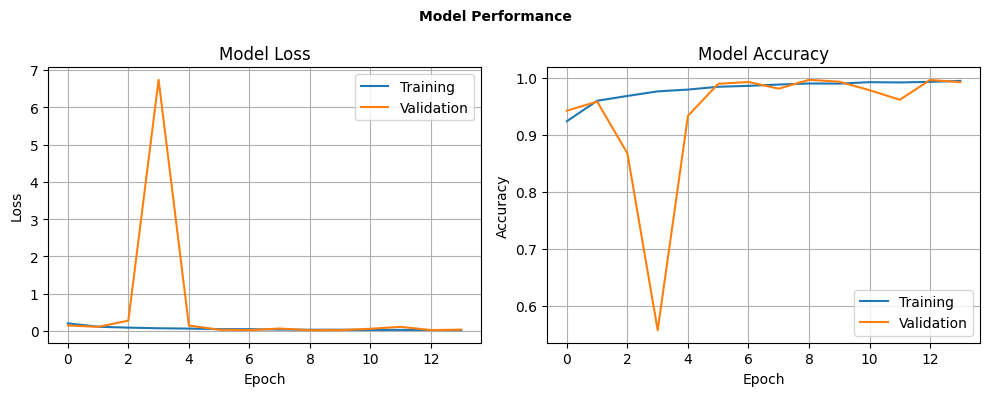

In [ ]:
import json
import matplotlib.pyplot as plt

# 1. Primero carga el archivo JSON
with open("C:\\Users\\historial.json") as f:
    historial = json.load(f)

# 2. Luego grafica usando la variable 'historial'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Pérdida ---
ax1.plot(historial['loss'], label='Training')
ax1.plot(historial['val_loss'], label='Validation')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# --- Precisión ---
ax2.plot(historial['accuracy'], label='Training')
ax2.plot(historial['val_accuracy'], label='Validation')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('Model Performance', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import os
import tensorflow as tf

# 1. Definir rutas (Asegúrate de que sean correctas en tu PC)
prueba_dir = dirc_pruebas
CAMARA_HEIGHT, CAMARA_WIDTH = 640, 640
LIDAR_HEIGHT, LIDAR_WIDTH = 19, 36
BATCH_SIZE = 16

# 2. Cargar los datasets individuales de prueba
prueba_camara_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prueba_dir, 'camara'),
    labels='inferred', label_mode='binary',
    image_size=(CAMARA_HEIGHT, CAMARA_WIDTH),
    batch_size=BATCH_SIZE, color_mode='rgb', shuffle=True, seed=42
)

prueba_lidar1_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prueba_dir, 'lidar1'),
    labels='inferred', label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE, color_mode='grayscale', shuffle=True, seed=42
)

prueba_lidar2_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(prueba_dir, 'lidar2'),
    labels='inferred', label_mode='binary',
    image_size=(LIDAR_HEIGHT, LIDAR_WIDTH),
    batch_size=BATCH_SIZE, color_mode='grayscale', shuffle=True, seed=42
)

# 3. Crear el prueba_ds combinado (La pieza que te faltaba)
def pair_datasets(camara_ds, lidar_ds, lidar2_ds):
    combined_ds = tf.data.Dataset.zip((camara_ds, lidar_ds, lidar2_ds))
    def format_pair(camara_batch, lidar_batch, lidar2_batch):
        return (
            {'camara_input': camara_batch[0], 
             'lidar_input': lidar_batch[0], 
             'lidar2_input': lidar2_batch[0]},
            camara_batch[1]
        )
    return combined_ds.map(format_pair)

prueba_ds = pair_datasets(prueba_camara_ds, prueba_lidar1_ds, prueba_lidar2_ds).prefetch(tf.data.AUTOTUNE)

print("¡Dataset 'prueba_ds' cargado correctamente!")

Found 3753 files belonging to 2 classes.
Found 3753 files belonging to 2 classes.
Found 3753 files belonging to 2 classes.
¡Dataset 'prueba_ds' cargado correctamente!


Calculando predicciones... Esto puede tardar unos segundos.


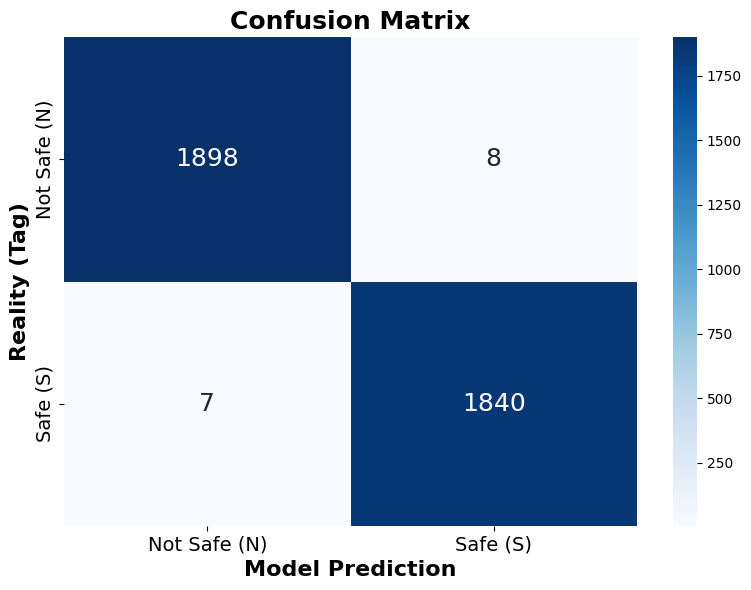


--- REPORTE DE MÉTRICAS ---
              precision    recall  f1-score   support

Not Safe (N)       1.00      1.00      1.00      1906
    Safe (S)       1.00      1.00      1.00      1847

    accuracy                           1.00      3753
   macro avg       1.00      1.00      1.00      3753
weighted avg       1.00      1.00      1.00      3753



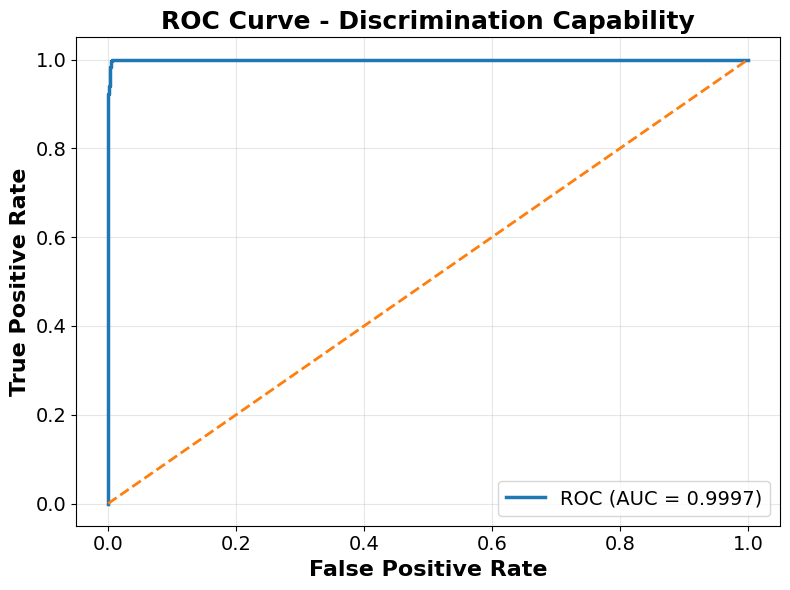

In [ ]:
# 1. DEFINICIÓN DE LA FUNCIÓN 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def generar_reporte_completo(modelo_ia, dataset_datos):
    y_true = []
    y_probs = []

    print("Calculando predicciones")
    for batch in dataset_datos:
        entradas, etiquetas = batch
        preds = modelo_ia.predict(entradas, verbose=0)
        y_probs.extend(preds.flatten())
        y_true.extend(etiquetas.numpy().flatten())

    y_true = np.array(y_true).astype(int)
    y_probs = np.array(y_probs)
    y_pred = (y_probs > 0.5).astype(int)

    # Gráfica 1: Matriz de Confusión
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        annot_kws={"size": 18},
        xticklabels=['Not Safe (N)', 'Safe (S)'],
        yticklabels=['Not Safe (N)', 'Safe (S)']
    )

    plt.title(
        'Confusion Matrix',
        fontsize=18,
        fontweight='bold'
    )

    plt.xlabel(
        'Model Prediction',
        fontsize=16,
        fontweight='bold'
    )

    plt.ylabel(
        'Reality (Tag)',
        fontsize=16,
        fontweight='bold'
    )

    # Tamaño de las etiquetas N y S
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.tight_layout()
    plt.show()

    # Reporte de texto
    print("\n--- REPORTE DE MÉTRICAS ---")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=['Not Safe (N)', 'Safe (S)']
        )
    )

    # Gráfica 2: Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2.5,
        label=f'ROC (AUC = {roc_auc:.4f})'
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--',
        linewidth=2
    )

    plt.title(
        'ROC Curve - Discrimination Capability',
        fontsize=18,
        fontweight='bold'
    )

    plt.xlabel(
        'False Positive Rate',
        fontsize=16,
        fontweight='bold'
    )

    plt.ylabel(
        'True Positive Rate',
        fontsize=16,
        fontweight='bold'
    )

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

generar_reporte_completo(mi_modelo, prueba_ds)

In [ ]:
import numpy as np
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,confusion_matrix, classification_report)
from tensorflow.keras.models import load_model

Modelo = load_model("modelo_estacionado.keras")

def evaluar_modelo(model, test_dataset, nombre_modelo="Modelo"):
    
    y_true = []
    y_prob = []

    # Obtener etiquetas reales y probabilidades
    for x_batch, y_batch in test_dataset:
        pred = model.predict(x_batch, verbose=0)

        y_true.extend(y_batch.numpy())
        y_prob.extend(pred.flatten())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    # Convertir probabilidades a clases
    y_pred = (y_prob >= 0.5).astype(int)

    # Calcular métricas
    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred)
    f1        = f1_score(y_true, y_pred)
    auc       = roc_auc_score(y_true, y_prob)
    matriz    = confusion_matrix(y_true, y_pred)

    # Mostrar resultados
    print(f"\n{'='*50}")
    print(f"Resultados: {nombre_modelo}")
    print(f"{'='*50}")

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"AUC-ROC  : {auc:.4f}")

    print("\nMatriz de Confusión:")
    print(matriz)

    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Regresar todo por si después quieres hacer gráficas
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": matriz,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
resultados_intermedio = evaluar_modelo(
    Modelo,
    prueba_ds,
    "fusion_intermedia"
)


Resultados: fusion_intermedia
Accuracy : 0.9960
Precision: 0.9957
Recall   : 0.9962
F1-Score : 0.9959
AUC-ROC  : 0.9997

Matriz de Confusión:
[[1898    8]
 [   7 1840]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1906
         1.0       1.00      1.00      1.00      1847

    accuracy                           1.00      3753
   macro avg       1.00      1.00      1.00      3753
weighted avg       1.00      1.00      1.00      3753

